In [ ]:
# ------------------------------------------------------------
# Import all the required libraries for data manipulation,
# preprocessing, ANN model building, visualization,
# and performance evaluation.
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# ------------------------------------------------------------
# Load the Employee Attrition dataset into a Pandas DataFrame
# and display the first five records.
# ------------------------------------------------------------

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
# ------------------------------------------------------------
# Display dataset information, shape, statistical summary,
# and check for missing values.
# ------------------------------------------------------------

print(df.info())
print(df.shape)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# ------------------------------------------------------------
# Convert the target column 'Attrition' from categorical
# values (Yes/No) into numerical values (1/0).
# ------------------------------------------------------------

df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Convert all categorical input features into numerical
# values using Label Encoding.
# ------------------------------------------------------------

label_cols = ['BusinessTravel', 'Department', 'EducationField',
              'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             80                

In [ ]:
# ------------------------------------------------------------
# Dropping the variables that have only one unique value as they do not contribute to the model.
# ------------------------------------------------------------

df = df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [ ]:
# ------------------------------------------------------------
# Separate the independent variables (features) and the
# dependent variable (target).
# ------------------------------------------------------------
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print(X.shape)
print(y.shape)

(1470, 31)
(1470,)


In [ ]:
# ------------------------------------------------------------
# Split the dataset into training and testing sets
# using an 80:20 ratio.
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 31)
(294, 31)


In [ ]:
# ------------------------------------------------------------
# Standardize the feature values using StandardScaler
# to improve ANN training performance.
# ------------------------------------------------------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ------------------------------------------------------------
# Build the Artificial Neural Network using Keras
# Sequential API with input, hidden, and output layers.
# ------------------------------------------------------------

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\yashg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ------------------------------------------------------------
# Compile the ANN model using the Adam optimizer,
# Binary Crossentropy loss function,
# and Accuracy evaluation metric.
# ------------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ------------------------------------------------------------
# Train the ANN model using the training dataset.
# Validation data is used to monitor performance.
# ------------------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8128 - loss: 0.4998 - val_accuracy: 0.8305 - val_loss: 0.4424
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8383 - loss: 0.4373 - val_accuracy: 0.8305 - val_loss: 0.4125
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8394 - loss: 0.4144 - val_accuracy: 0.8305 - val_loss: 0.3922
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8436 - loss: 0.4003 - val_accuracy: 0.8305 - val_loss: 0.3714
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8457 - loss: 0.3816 - val_accuracy: 0.8347 - val_loss: 0.3561
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8511 - loss: 0.3627 - val_accuracy: 0.8475 - val_loss: 0.3465
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8479 - loss: 0.3563 - val_accuracy: 0.8517 - val_loss: 0.3417
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8606 - loss: 0.3501 - val_accuracy: 0.8686 - val_loss:

In [ ]:
# ------------------------------------------------------------
# Evaluate the trained ANN model on the testing dataset
# and display the testing accuracy.
# ------------------------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8810 - loss: 0.4868 
Test Loss: 0.4868
Test Accuracy: 88.10%


In [ ]:
# ------------------------------------------------------------
# Predict employee attrition on the testing dataset
# and convert prediction probabilities into
# binary class labels (0 or 1).
# ------------------------------------------------------------

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)
print(y_pred[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]]


[[239   8]
 [ 27  20]]


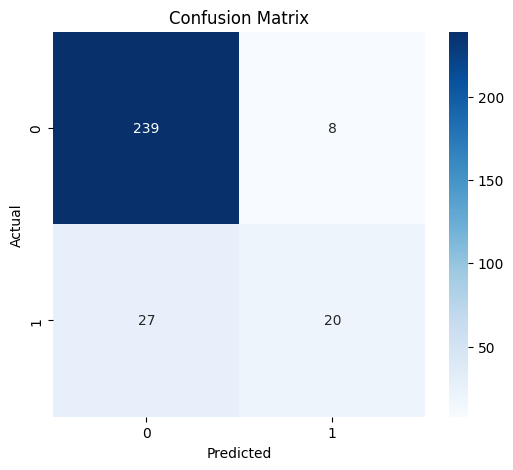

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       247
           1       0.71      0.43      0.53        47

    accuracy                           0.88       294
   macro avg       0.81      0.70      0.73       294
weighted avg       0.87      0.88      0.87       294



In [ ]:
# ------------------------------------------------------------
# Generate and visualize the confusion matrix
# to evaluate classification performance.
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred))

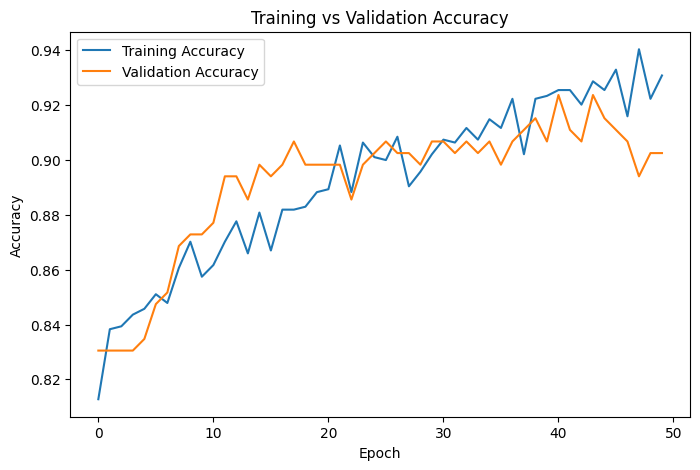

In [ ]:
# ------------------------------------------------------------
# Plot Training Accuracy and Validation Accuracy
# across all epochs.
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
# ==============================================================
# SYNOPSIS
# --------------------------------------------------------------
# In this assignment, we implemented an Artificial Neural Network
# (ANN) using TensorFlow/Keras to solve a binary classification
# problem, Employee Attrition Prediction.
#
# First, we imported all the required libraries such as Pandas,
# NumPy, Matplotlib, Seaborn, Scikit-learn, and TensorFlow.
#
# Next, we loaded the Employee Attrition dataset and explored it
# by checking its shape, information, and missing values.
#
# Since machine learning models work with numerical data, we
# converted all categorical features into numerical values using
# Label Encoding. We also converted the target column
# (Attrition) into binary values:
#      Yes = 1
#      No  = 0
#
# After preprocessing, we separated the dataset into input
# features (X) and target variable (y). The data was then split
# into training and testing sets using an 80:20 ratio.
#
# To improve model performance, we standardized all input
# features using StandardScaler.
#
# We built an Artificial Neural Network (ANN) using the Keras
# Sequential API. The model consists of one input layer, two
# hidden layers with ReLU activation, a Dropout layer to reduce
# overfitting, and one output layer with Sigmoid activation for
# binary classification.
#
# The model was compiled using the Adam optimizer and Binary
# Crossentropy loss function. It was trained for multiple epochs
# using the training dataset while validating its performance on
# validation data.
#
# After training, the model was evaluated using the testing
# dataset. We calculated Accuracy, generated the Confusion
# Matrix, and displayed the Classification Report containing
# Precision, Recall, and F1-Score.
#
# Finally, we plotted the Accuracy and Loss graphs to observe
# the learning performance of the ANN model during training.
#
# This assignment helped us understand how Artificial Neural
# Networks can be used for binary classification problems and
# how different preprocessing, training, and evaluation
# techniques improve prediction performance.
# ==============================================================